In [19]:
import seaborn as sns
from sklearn.datasets import make_blobs
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

In [2]:
X,y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)

<Axes: >

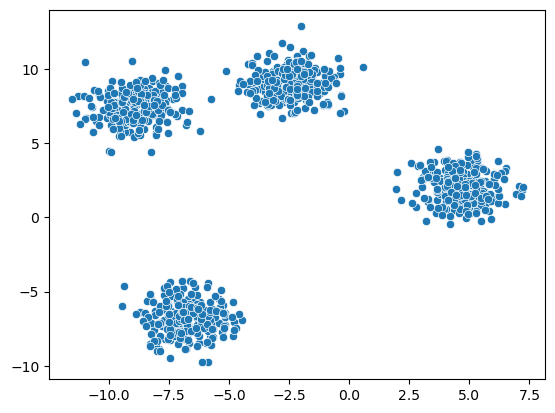

In [3]:
#Visualize
sns.scatterplot(x=X[:,0],y=X[:,1])

In [14]:

from sklearn.cluster import KMeans

In [17]:
K = 4

kmeans = KMeans(
    n_clusters = K,
    random_state = 42
)

In [20]:
labels = kmeans.fit_predict(X)

<Axes: >

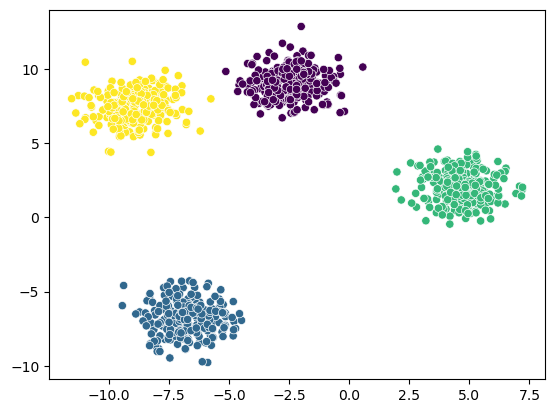

In [11]:
sns.scatterplot(x=X[:,0],y=X[:,1],c=labels)

# Elbow Method

In [21]:
wcss = []

for k in range(1,21):
    kmeans = KMeans(n_clusters = k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)

In [23]:
wcss

[66908.28490516872,
 45166.22936887345,
 7324.56056474156,
 1948.7329193856835,
 1795.8161307411642,
 1625.140803025291,
 1435.9938156217868,
 1329.3991142045463,
 1176.2110385473964,
 1045.2597011458713,
 950.184533643274,
 937.1500934203593,
 903.4727610993937,
 796.6543366667962,
 759.7014940420455,
 710.0023514752851,
 652.1166311254774,
 640.9050009496377,
 602.9318757079975,
 582.8196525878141]

<Axes: >

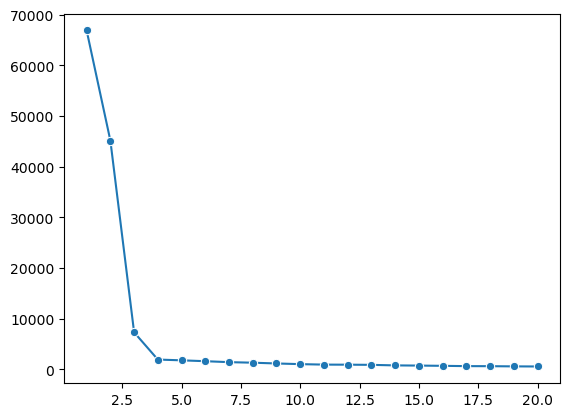

In [22]:
sns.lineplot(x=range(1,21),y=wcss,marker='o')

In [24]:
!pip install kneed

In [25]:
from kneed import KneeLocator

In [26]:
knee = KneeLocator(range(1,21),wcss,curve = "convex",direction="decreasing")

In [27]:
print("optimal k =",knee.elbow)

optimal k = 4


# Silhouette Score

In [29]:
from sklearn.metrics import silhouette_score

In [31]:
ss = []

for k in range(2,21):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X,labels)

    ss.append(score)

<Axes: >

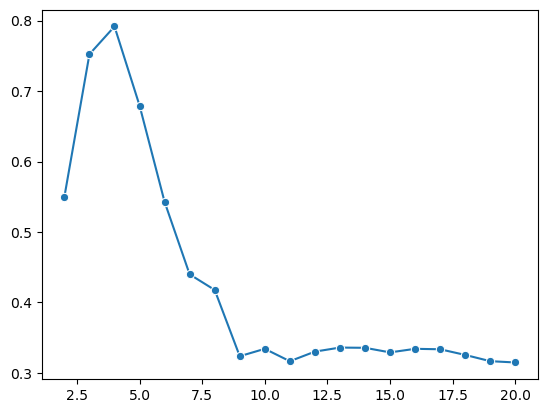

In [37]:
sns.lineplot(x=range(2,21),y=ss,marker='o')